#### <p style="text-align: center;">Tarea 2 – Análisis de Datos, Tendencias Tecnológicas y metodologías<br>EDA</p>

<p style="text-align: center;">Camilo Eduardo Ariza Camacho<br>1101759700</p>

<p style="text-align: center;">Minería para Big Data<br>Grupo 2</p>   

<p style="text-align: center;">UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD</p>

<p style="text-align: center;">Bogotá, Marzo 17</p>

### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
#Spark
import findspark
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col, sum, avg, count, max, min, stddev,
    month, year, quarter, dayofweek, lag,
    round, when, to_date, percentile_approx
)

### Spark

In [2]:
#Conexión 
findspark.init()
spark = SparkSession.builder \
    .appName("EDA_MBD_T2_UNAD") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate() 

#Leer data
df = spark.read.csv(
    "ventas_2023.csv",
    header=True,
    inferSchema=True
)

df = df.withColumn("fecha", to_date(col("fecha"), "yyyy-MM-dd"))

print(f"Dataset cargado: {df.count():,} registros - {len(df.columns)} columnas")
df.printSchema()
df.show(5, truncate=False)



Dataset cargado: 365 registros - 8 columnas
root
 |-- fecha: date (nullable = true)
 |-- monto: double (nullable = true)
 |-- producto: string (nullable = true)
 |-- region: string (nullable = true)
 |-- tipo_pago: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- dia_semana: string (nullable = true)

+----------+-------+----------+------+---------+--------+---+----------+
|fecha     |monto  |producto  |region|tipo_pago|cantidad|mes|dia_semana|
+----------+-------+----------+------+---------+--------+---+----------+
|2023-01-01|786.92 |Smartphone|Este  |Crédito  |5       |1  |Domingo   |
|2023-01-02|1211.86|Smartwatch|Oeste |Débito   |10      |1  |Lunes     |
|2023-01-03|1072.96|Smartphone|Este  |Crédito  |6       |1  |Martes    |
|2023-01-04|713.16 |Smartwatch|Este  |Efectivo |3       |1  |Miércoles |
|2023-01-05|907.09 |Laptop    |Oeste |Crédito  |2       |1  |Jueves    |
+----------+-------+----------+------+---------+--------

### EDA

##### Indicadores globales

In [3]:
kpis = df.agg(
    sum("monto").alias("ingresos_totales"),
    avg("monto").alias("ticket_promedio_diario"),
    count("*").alias("dias_registrados"),
    min("monto").alias("venta_minima"),
    max("monto").alias("venta_maxima"),
    stddev("monto").alias("desviacion_estandar"),
    min("fecha").alias("fecha_inicio"),
    max("fecha").alias("fecha_fin")
).toPandas()

print("=" * 60)
print("  RESUMEN EJECUTIVO – VENTAS 2023")
print("=" * 60)
for campo, valor in kpis.iloc[0].items():
    print(f"  {campo:<30}: {valor}")
print("=" * 60)


  RESUMEN EJECUTIVO – VENTAS 2023
  ingresos_totales              : 362633.64999999997
  ticket_promedio_diario        : 993.5168493150684
  dias_registrados              : 365
  venta_minima                  : 329.35
  venta_maxima                  : 1964.62
  desviacion_estandar           : 307.4996977541478
  fecha_inicio                  : 2023-01-01
  fecha_fin                     : 2023-12-31


##### Calidad e integridad de los datos

In [4]:
#Nulos
print("Nulos por columna:")
nulos = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas().T.rename(columns={0: "nulos"})
nulos["pct"] = (nulos["nulos"] / df.count() * 100).round(2)
print(nulos[nulos["nulos"] > 0].to_string()
      if nulos["nulos"].sum() > 0
      else "   Sin valores nulos")

#Duplicados
n_dup = df.count() - df.dropDuplicates().count()
print(f"\nDuplicados: {n_dup}")

#Outliers
inv = df.filter(col("monto") <= 0).count()
print(f"\nMontos ≤ 0: {inv}")

#Cardinalidad de variables categóricas
print("\nValores únicos por variable categórica:")
for c in ["producto", "region", "tipo_pago", "dia_semana"]:
    n   = df.select(c).distinct().count()
    vals = [r[c] for r in df.select(c).distinct().collect()]
    print(f"   {c:<15}: {n} valores → {vals}")


Nulos por columna:
   Sin valores nulos

Duplicados: 0

Montos ≤ 0: 0

Valores únicos por variable categórica:
   producto       : 4 valores → ['Smartwatch', 'Smartphone', 'Laptop', 'Tablet']
   region         : 4 valores → ['Oeste', 'Sur', 'Este', 'Norte']
   tipo_pago      : 3 valores → ['Crédito', 'Efectivo', 'Débito']
   dia_semana     : 7 valores → ['Domingo', 'Miércoles', 'Jueves', 'Sábado', 'Martes', 'Viernes', 'Lunes']


##### Enriquecimiento del dataframe

In [5]:
#Variables temporales
df = df.withColumn("trimestre",    quarter(col("fecha"))) \
       .withColumn("num_dia",      dayofweek(col("fecha"))) \
       .withColumn("ingreso_total",
                   round(col("monto") * col("cantidad"), 2))

#Segmentación del monto por percentiles
p33, p66 = df.approxQuantile("monto", [0.33, 0.66], 0.01)
df = df.withColumn("segmento",
    when(col("monto") <= p33, "Bajo")
   .when(col("monto") <= p66, "Medio")
   .otherwise("Alto"))

print("Segmentación por percentiles:")
print(f"Bajo (P0-P33):   $0        - ${p33:,.2f}")
print(f"Medio (P33-P66): ${p33:,.2f}   -  ${p66:,.2f}")
print(f"Alto (P66-P100): ${p66:,.2f} - ${df.agg(max("monto").alias("monto")).first()["monto"]:,.2f}")

print(f"\nVariables creadas")
df.select("fecha", "monto", "cantidad",
          "ingreso_total", "segmento", "trimestre").show(5)


Segmentación por percentiles:
Bajo (P0-P33):   $0        - $822.31
Medio (P33-P66): $822.31   -  $1,076.71
Alto (P66-P100): $1,076.71 - $1,964.62

Variables creadas
+----------+-------+--------+-------------+--------+---------+
|     fecha|  monto|cantidad|ingreso_total|segmento|trimestre|
+----------+-------+--------+-------------+--------+---------+
|2023-01-01| 786.92|       5|       3934.6|    Bajo|        1|
|2023-01-02|1211.86|      10|      12118.6|    Alto|        1|
|2023-01-03|1072.96|       6|      6437.76|   Medio|        1|
|2023-01-04| 713.16|       3|      2139.48|    Bajo|        1|
|2023-01-05| 907.09|       2|      1814.18|   Medio|        1|
+----------+-------+--------+-------------+--------+---------+
only showing top 5 rows


##### Análisis de distribución de la data

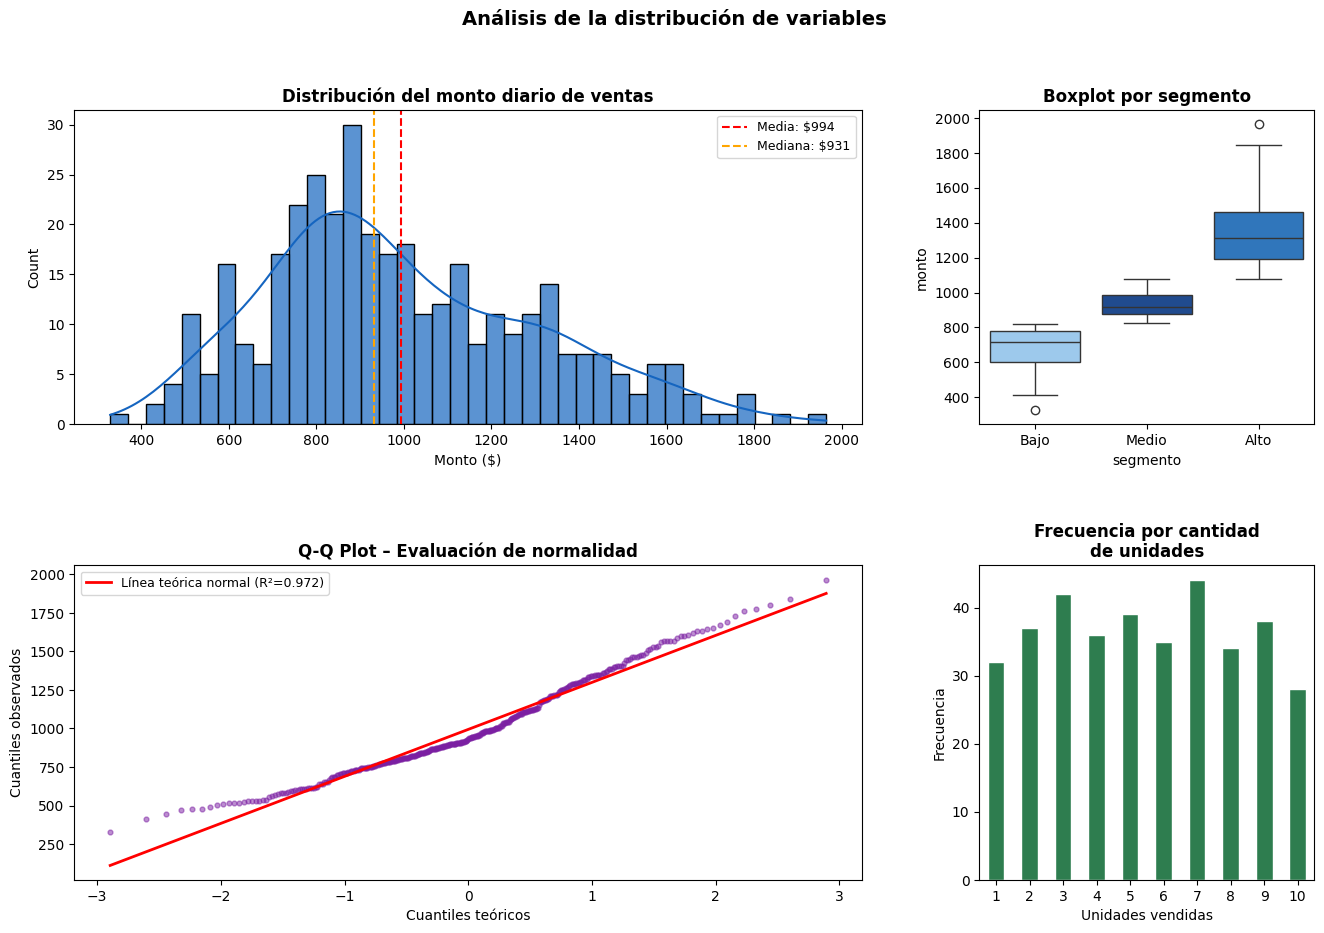

In [6]:
montos_pd = df.select("monto", "cantidad", "ingreso_total", "segmento").toPandas()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

#Histograma, KDE y líneas de media y mediana
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(montos_pd["monto"], bins=40, kde=True,
             color="#1565c0", ax=ax1, alpha=0.7)
ax1.axvline(montos_pd["monto"].mean(),
            color="red", linestyle="--", linewidth=1.5,
            label=f'Media: ${montos_pd["monto"].mean():,.0f}')
ax1.axvline(montos_pd["monto"].median(),
            color="orange", linestyle="--", linewidth=1.5,
            label=f'Mediana: ${montos_pd["monto"].median():,.0f}')
ax1.set_title("Distribución del monto diario de ventas",
              fontweight="bold")
ax1.set_xlabel("Monto ($)")
ax1.legend(fontsize=9)

#Boxplot por segmento
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=montos_pd, y="monto", x="segmento",
            order=["Bajo", "Medio", "Alto"], hue="segmento",
            palette=["#90caf9", "#1976d2", "#0d47a1"], ax=ax2)
ax2.set_title("Boxplot por segmento", fontweight="bold")

#QQ Plot
ax3 = fig.add_subplot(gs[1, :2])
(osm, osr), (slope, intercept, r) = stats.probplot(
    montos_pd["monto"].dropna(), dist="norm")
ax3.scatter(osm, osr, alpha=0.5, s=12, color="#7b1fa2")
ax3.plot(osm, slope * np.array(osm) + intercept,
         color="red", linewidth=2,
         label=f"Línea teórica normal (R²={r**2:.3f})")
ax3.set_title("Q-Q Plot – Evaluación de normalidad",
              fontweight="bold")
ax3.set_xlabel("Cuantiles teóricos")
ax3.set_ylabel("Cuantiles observados")
ax3.legend(fontsize=9)

#Distribución de cantidad de items por venta
ax4 = fig.add_subplot(gs[1, 2])
montos_pd["cantidad"].value_counts().sort_index().plot(
    kind="bar", ax=ax4, color="#2e7d4f",
    edgecolor="white")
ax4.set_title("Frecuencia por cantidad\nde unidades",
              fontweight="bold")
ax4.set_xlabel("Unidades vendidas")
ax4.set_ylabel("Frecuencia")
ax4.tick_params(axis="x", rotation=0)

fig.suptitle("Análisis de la distribución de variables",
             fontsize=14, fontweight="bold")
plt.show()


##### Tendencia con promedio móvil y variación mensual

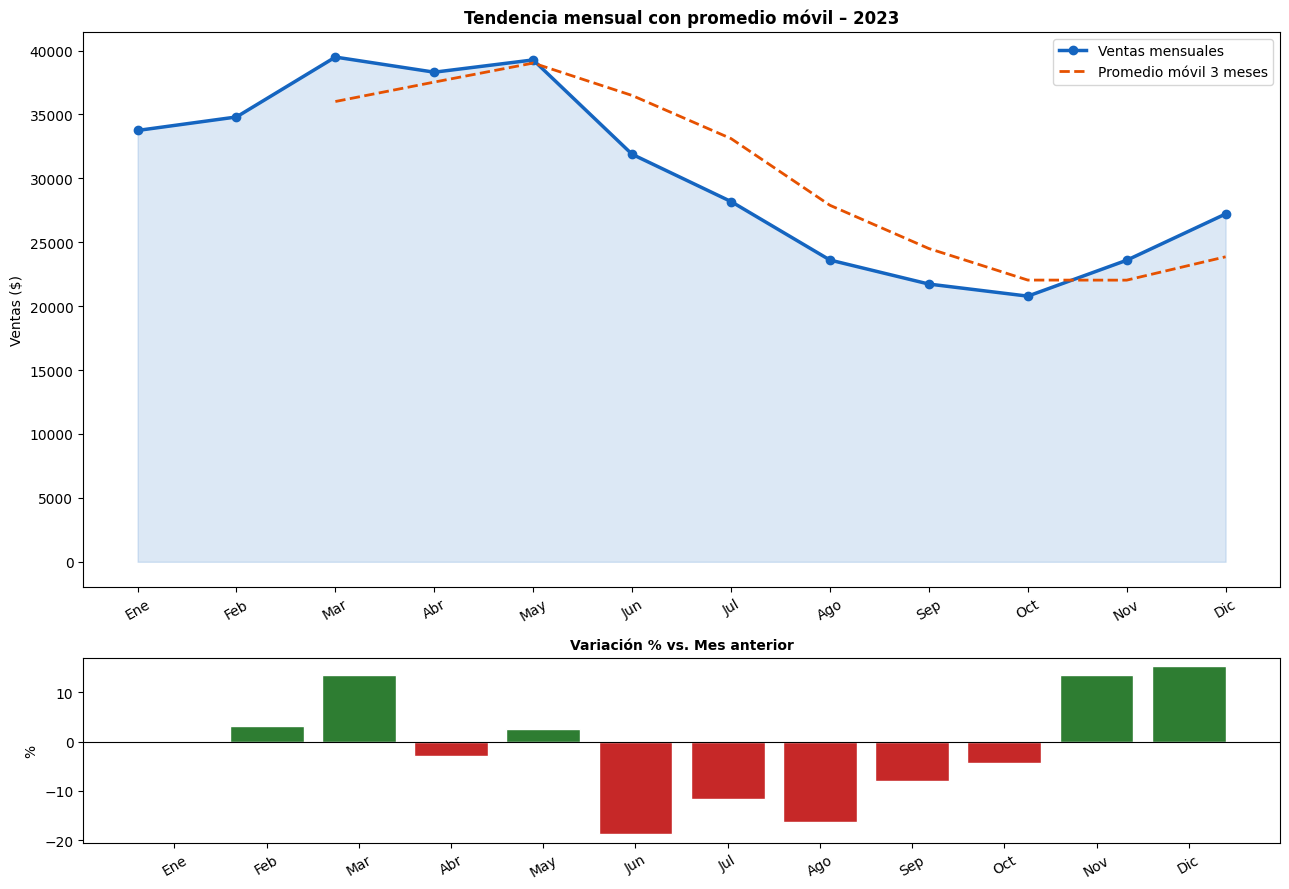

In [7]:
w = Window.orderBy("mes")

ventas_mes = df.groupBy("mes") \
    .agg(
        round(sum("monto"),  2).alias("ventas_totales"),
        round(avg("monto"),  2).alias("ticket_promedio"),
        round(sum("ingreso_total"), 2).alias("ingreso_total"),
        count("*").alias("dias")
    ) \
    .orderBy("mes") \
    .withColumn("ventas_anterior",
                lag("ventas_totales", 1).over(w)) \
    .withColumn("variacion_pct",
        round((col("ventas_totales") - col("ventas_anterior")) /
               col("ventas_anterior") * 100, 2)) \
    .toPandas()

nombres_mes = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
               7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
ventas_mes["nombre"] = ventas_mes["mes"].map(nombres_mes)

#Promedio móvil de 3 meses
ventas_mes["ma3"] = ventas_mes["ventas_totales"].rolling(3).mean()

#Tendencia y variación
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
    gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(ventas_mes["nombre"], ventas_mes["ventas_totales"],
         color="#1565c0", linewidth=2.5, marker="o",
         markersize=6, label="Ventas mensuales")
ax1.plot(ventas_mes["nombre"], ventas_mes["ma3"],
         color="#e65100", linewidth=2, linestyle="--",
         label="Promedio móvil 3 meses")
ax1.fill_between(ventas_mes["nombre"],
                 ventas_mes["ventas_totales"],
                 alpha=0.15, color="#1565c0")
ax1.set_title("Tendencia mensual con promedio móvil – 2023",
              fontweight="bold")
ax1.set_ylabel("Ventas ($)")
ax1.legend()
ax1.tick_params(axis="x", rotation=30)

colores_var = ["#2e7d32" if (v and v >= 0) else "#c62828"
               for v in ventas_mes["variacion_pct"].fillna(0)]
ax2.bar(ventas_mes["nombre"],
        ventas_mes["variacion_pct"].fillna(0),
        color=colores_var, edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Variación % vs. Mes anterior",
              fontweight="bold", fontsize=10)
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()



##### Estacionalidad por mes

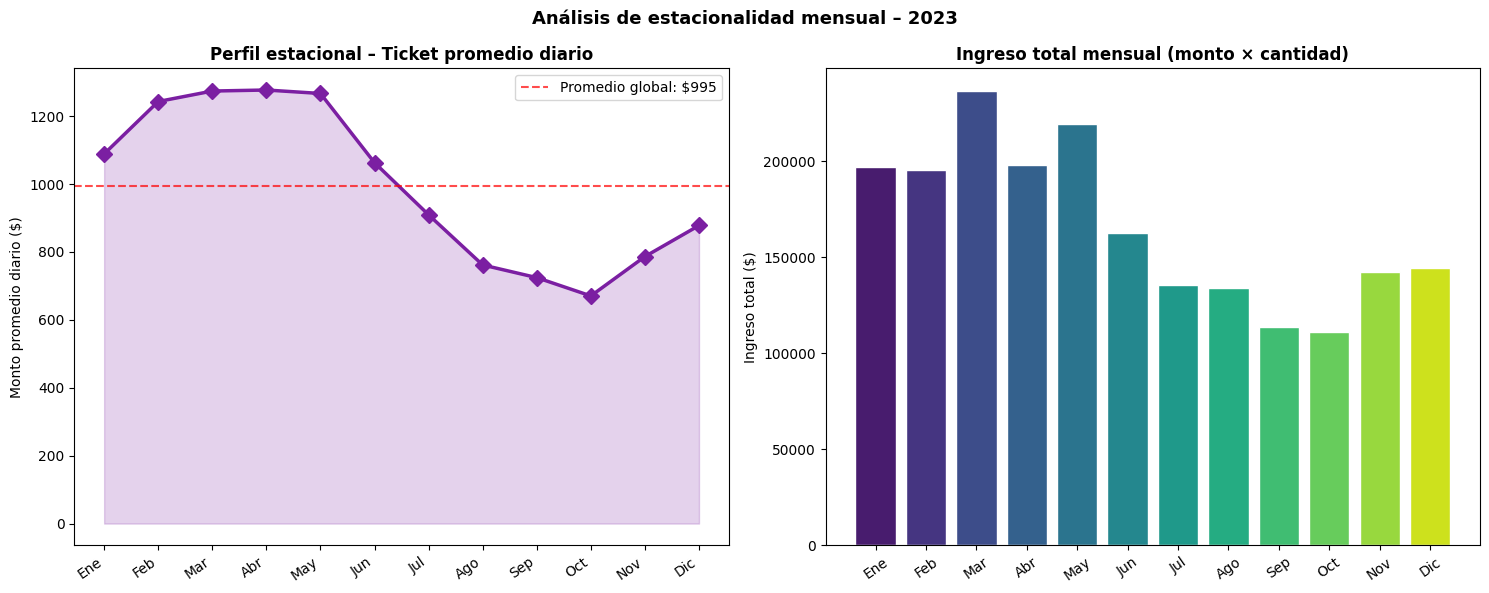

In [8]:
estacional = ventas_mes.copy()

#Perfil estacional
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Curva estacional con línea de promedio global
axes[0].plot(estacional["nombre"], estacional["ticket_promedio"],
             marker="D", color="#7b1fa2", linewidth=2.5,
             markersize=8)
axes[0].fill_between(range(len(estacional)),
                     estacional["ticket_promedio"],
                     alpha=0.2, color="#7b1fa2")
axes[0].axhline(estacional["ticket_promedio"].mean(),
                color="red", linestyle="--", alpha=0.7,
                label=f'Promedio global: ${estacional["ticket_promedio"].mean():,.0f}')
axes[0].set_xticks(range(len(estacional)))
axes[0].set_xticklabels(estacional["nombre"],
                         rotation=35, ha="right")
axes[0].set_title("Perfil estacional – Ticket promedio diario",
                  fontweight="bold")
axes[0].set_ylabel("Monto promedio diario ($)")
axes[0].legend()

#Ingreso total por mes
colors_mes = sns.color_palette("viridis", 12)
axes[1].bar(estacional["nombre"], estacional["ingreso_total"],
            color=colors_mes, edgecolor="white")
axes[1].set_title("Ingreso total mensual (monto × cantidad)",
                  fontweight="bold")
axes[1].set_ylabel("Ingreso total ($)")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Análisis de estacionalidad mensual – 2023",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



##### Análisis de variables categóricas

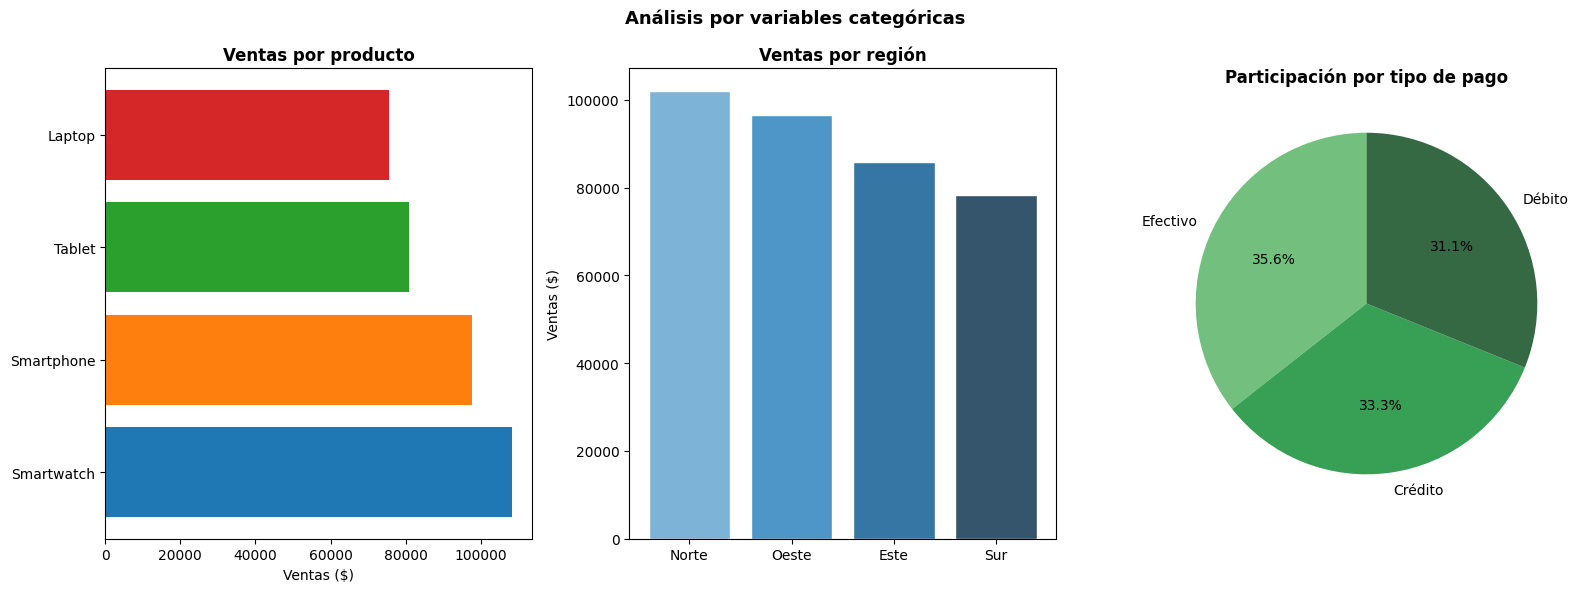

In [9]:
#Ventas por producto
prod_pd = df.groupBy("producto") \
    .agg(
        round(sum("monto"),         2).alias("ventas_totales"),
        round(avg("monto"),         2).alias("promedio"),
        round(sum("ingreso_total"), 2).alias("ingreso_total"),
        count("*").alias("dias")
    ).orderBy(col("ventas_totales").desc()).toPandas()

#Ventas por región
reg_pd = df.groupBy("region") \
    .agg(
        round(sum("monto"),  2).alias("ventas_totales"),
        round(avg("monto"),  2).alias("promedio")
    ).orderBy(col("ventas_totales").desc()).toPandas()

#Ventas por tipo de pago
pago_pd = df.groupBy("tipo_pago") \
    .agg(
        round(sum("monto"),  2).alias("ventas_totales"),
        count("*").alias("dias")
    ).orderBy(col("ventas_totales").desc()).toPandas()

#Panel de categorías
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

#Producto - Barras horizontales
colors_p = sns.color_palette("tab10", len(prod_pd))
axes[0].barh(prod_pd["producto"], prod_pd["ventas_totales"],
             color=colors_p)
axes[0].set_title("Ventas por producto", fontweight="bold")
axes[0].set_xlabel("Ventas ($)")

#Región - Barras verticales
axes[1].bar(reg_pd["region"], reg_pd["ventas_totales"],
            color=sns.color_palette("Blues_d", len(reg_pd)),
            edgecolor="white")
axes[1].set_title("Ventas por región", fontweight="bold")
axes[1].set_ylabel("Ventas ($)")

#Tipo de pago - Pie
axes[2].pie(pago_pd["ventas_totales"],
            labels=pago_pd["tipo_pago"],
            autopct="%1.1f%%",
            colors=sns.color_palette("Greens_d", len(pago_pd)),
            startangle=90)
axes[2].set_title("Participación por tipo de pago",
                  fontweight="bold")

plt.suptitle("Análisis por variables categóricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


##### Composición por segmento en el tiempo

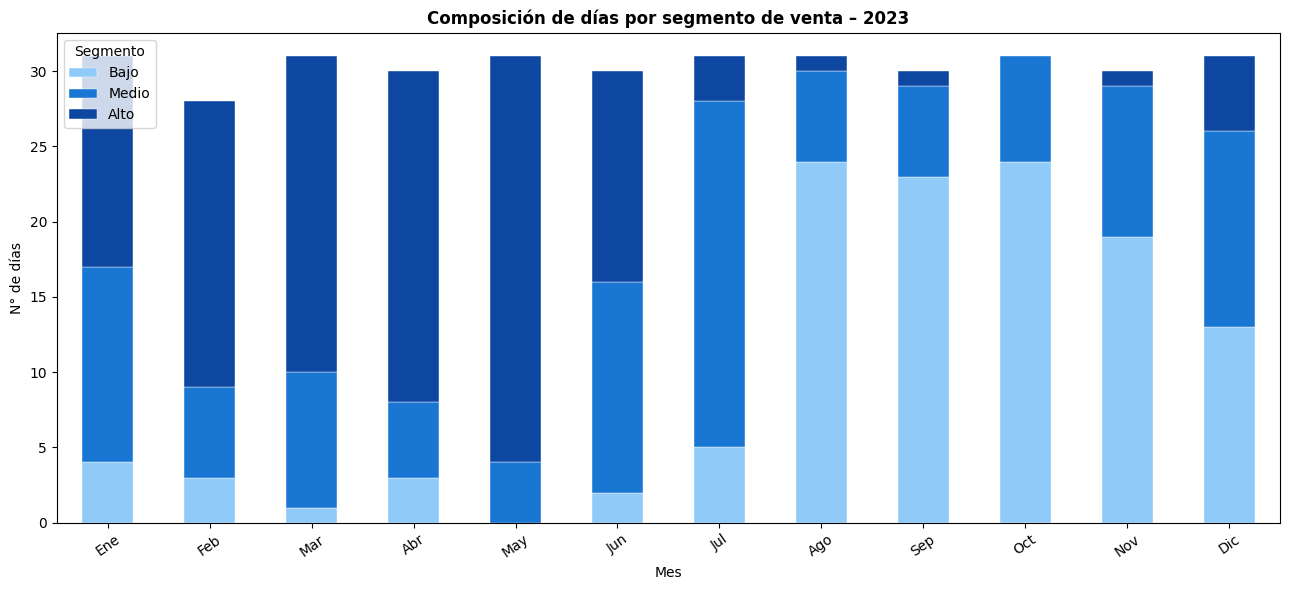

In [10]:
seg_tiempo = df.groupBy("mes", "segmento") \
    .agg(count("*").alias("dias")) \
    .orderBy("mes") \
    .toPandas()

pivot_seg = seg_tiempo.pivot_table(
    index="mes", columns="segmento",
    values="dias", fill_value=0
)[["Bajo", "Medio", "Alto"]]
pivot_seg.index = [nombres_mes[m] for m in pivot_seg.index]

#Composición por segmento
fig, ax = plt.subplots(figsize=(13, 6))
pivot_seg.plot(kind="bar", stacked=True, ax=ax,
               color=["#90caf9", "#1976d2", "#0d47a1"],
               edgecolor="white", linewidth=0.3)
ax.set_title("Composición de días por segmento de venta – 2023",
             fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("N° de días")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Segmento", loc="upper left")
plt.tight_layout()
plt.show()


##### Correlaciones entre variables numéricas

Correlaciones:
   monto           ↔   cantidad       : +0.0602
   monto           ↔   mes            : -0.5902
   cantidad        ↔   mes            : -0.0178
   monto           ↔   ingreso_total  : +0.5404


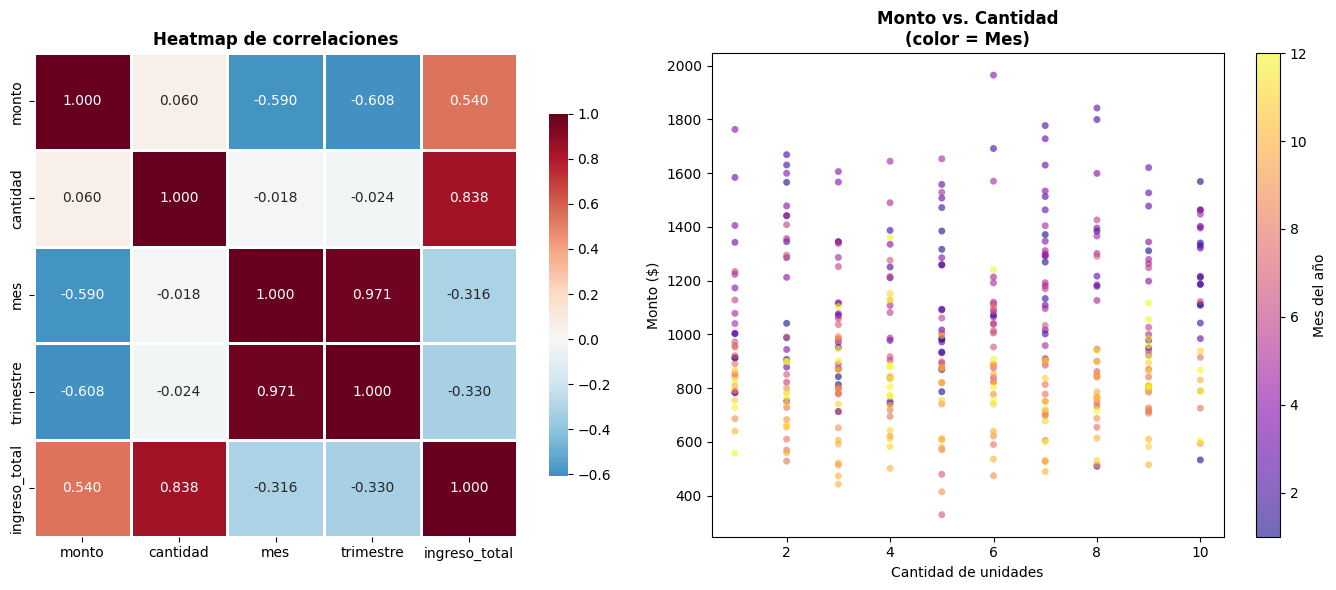

In [11]:
print("Correlaciones:")
pares = [("monto","cantidad"), ("monto","mes"),
         ("cantidad","mes"), ("monto","ingreso_total")]
for v1, v2 in pares:
    r = df.stat.corr(v1, v2)
    print(f"   {v1:15} ↔   {v2:15}: {r:+.4f}")

#Heatmap y scatter
df_num = df.select("monto","cantidad","mes", "trimestre","ingreso_total").toPandas()

#Correlaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(df_num.corr(), annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, square=True,
            linewidths=0.8, ax=axes[0],
            cbar_kws={"shrink": 0.75})
axes[0].set_title("Heatmap de correlaciones", fontweight="bold")

sc = axes[1].scatter(df_num["cantidad"], df_num["monto"],
                     c=df_num["mes"], cmap="plasma",
                     alpha=0.6, s=25, edgecolors="none")
plt.colorbar(sc, ax=axes[1], label="Mes del año")
axes[1].set_title("Monto vs. Cantidad\n(color = Mes)",
                  fontweight="bold")
axes[1].set_xlabel("Cantidad de unidades")
axes[1].set_ylabel("Monto ($)")

plt.tight_layout()
plt.show()


##### Detección y distribución de outliers

IQR: $415.04 | Límites: $154.84 – $1,815.00
 es_outlier   n  monto_prom
      False 363      988.50
       True   2     1903.48


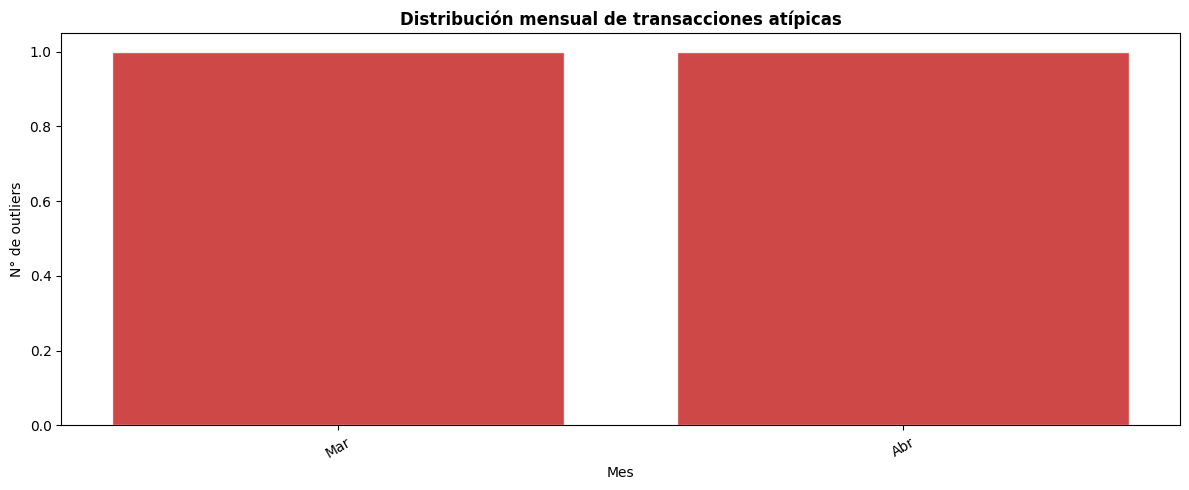

In [12]:
Q1, Q3 = df.approxQuantile("monto", [0.25, 0.75], 0.01)
IQR    = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR

df_out = df.withColumn("es_outlier",
    when((col("monto") < lim_inf) |
         (col("monto") > lim_sup), True).otherwise(False))

resumen = df_out.groupBy("es_outlier") \
    .agg(count("*").alias("n"),
         round(avg("monto"), 2).alias("monto_prom")) \
    .toPandas()

print(f"IQR: ${IQR:,.2f} | Límites: ${lim_inf:,.2f} – ${lim_sup:,.2f}")
print(resumen.to_string(index=False))

#Outliers por mes
out_mes = df_out.filter(col("es_outlier") == True) \
    .groupBy("mes").agg(count("*").alias("n_outliers")) \
    .orderBy("mes").toPandas()
out_mes["nombre"] = out_mes["mes"].map(nombres_mes)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(out_mes["nombre"], out_mes["n_outliers"],
       color="#c62828", alpha=0.85, edgecolor="white")
ax.set_title("Distribución mensual de transacciones atípicas",
             fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("N° de outliers")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


##### Resumen de patrones con SparkSQL

In [13]:
df.createOrReplaceTempView("ventas")

print("=" * 58)
print("  SÍNTESIS DE PATRONES DETECTADOS – 2023")
print("=" * 58)

print("\n📅 Top 3 meses por ventas:")
spark.sql("""
    SELECT mes,
           ROUND(SUM(monto), 2)  AS ventas_totales,
           ROUND(AVG(monto), 2)  AS ticket_diario
    FROM ventas GROUP BY mes
    ORDER BY ventas_totales DESC LIMIT 3
""").show()

print("🏆 Ranking de productos:")
spark.sql("""
    SELECT producto,
           COUNT(*)             AS dias,
           ROUND(SUM(monto),2)  AS total,
           ROUND(AVG(monto),2)  AS promedio
    FROM ventas GROUP BY producto
    ORDER BY total DESC
""").show()

print("🗺️  Ranking de regiones:")
spark.sql("""
    SELECT region,
           ROUND(SUM(monto),2) AS total,
           ROUND(AVG(monto),2) AS promedio
    FROM ventas GROUP BY region
    ORDER BY total DESC
""").show()

print("💳 Preferencia de pago:")
spark.sql("""
    SELECT tipo_pago,
           COUNT(*) AS dias,
           ROUND(SUM(monto),2) AS total
    FROM ventas GROUP BY tipo_pago
    ORDER BY total DESC
""").show()


  SÍNTESIS DE PATRONES DETECTADOS – 2023

📅 Top 3 meses por ventas:
+---+--------------+-------------+
|mes|ventas_totales|ticket_diario|
+---+--------------+-------------+
|  3|      39491.46|      1273.92|
|  5|      39269.01|      1266.74|
|  4|      38308.23|      1276.94|
+---+--------------+-------------+

🏆 Ranking de productos:
+----------+----+---------+--------+
|  producto|dias|    total|promedio|
+----------+----+---------+--------+
|Smartwatch| 108|108294.48| 1002.73|
|Smartphone|  97| 97673.12| 1006.94|
|    Tablet|  79| 80996.24| 1025.27|
|    Laptop|  81| 75669.81|   934.2|
+----------+----+---------+--------+

🗺️  Ranking de regiones:
+------+--------+--------+
|region|   total|promedio|
+------+--------+--------+
| Norte|102062.5| 1010.52|
| Oeste|96425.38|  983.93|
|  Este|85770.63| 1021.08|
|   Sur|78375.14|  955.79|
+------+--------+--------+

💳 Preferencia de pago:
+---------+----+---------+
|tipo_pago|dias|    total|
+---------+----+---------+
| Efectivo| 123|129

### Cierre de la Sesión de Spark

In [ ]:
spark.stop()
print("Sesión de Spark cerrada correctamente")

Sesión de Spark cerrada correctamente
